In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from tqdm import tqdm

# Constants
m = 0.5
w = 1
hbar = 1


N = 200       
V_height = 50   

barrier_start = 2
barrier_end = 8

global L_max
L_min = 10
L_max = 50
L_steps = 1200

L_arr = np.linspace(L_min, L_max, L_steps)



def V_matrix_well(L, N, height, R1, R2):
    """
    Using specific trig rule for integrating sin(ax)sin(bx) :
    https://en.wikipedia.org/wiki/List_of_integrals_of_trigonometric_functions#Integrands_involving_only_sine
    """
    n = np.arange(1, N + 1)
    i, j = np.meshgrid(n, n, indexing='ij')

    def V_integral(r):
        term_1 = np.sinc((i-j)*r/L) * (r/L)
        term_2 = np.sinc((i+j)*r/L) * (r/L)
        return term_1 - term_2

    V_mat = height * (V_integral(R2) - V_integral(R1))
    return V_mat

def V_matrix_sphere(L, N, A):
    r_grid = np.linspace(0, L, 2000)
    dr = r_grid[1] - r_grid[0]

    V_r = A * (r_grid**2) * np.exp(-r_grid)

    n_indices = np.arange(1, N + 1).reshape(-1, 1)
    phi = np.sqrt(2/L) * np.sin(n_indices * np.pi * r_grid / L)

    V_mat = (phi * V_r) @ phi.T * dr

    return V_mat

In [ ]:
T_num = (hbar**2 * n**2 * np.pi**2) / (2 * m)


eigs_arr = []
dipoles_arr = []

A = 7.5

def get_dipole(L,N):
    r_grid = np.linspace(0,L,2000)
    psi = lambda r: 10*np.exp(-(r)**2/(2*2))
    dr = r_grid[1]-r_grid[0]
    psi0 = psi(r_grid)

    norm = np.sqrt(np.sum(psi0**2) * dr)
    psi0 = psi0 / norm

    n_vec = np.arange(1, N + 1).reshape(-1, 1)
    phi = np.sqrt(2/L) * np.sin(n_vec * np.pi * r_grid / L)
    M = np.sum(phi * (psi0 * r_grid), axis=1) * dr
    return M



for L in tqdm(L_arr):

    T_mat = np.diag(T_num / L**2)
    

    #V_mat = V_matrix_well(L, N, V_height, barrier_start, barrier_end)
    V_mat = V_matrix_sphere(L,N,A)
    
    H = T_mat + V_mat
    #Only get first 50 eigenvalues, otherwise its reaaaaaaaaaaalllllllly slow
    energies, evecs = sp.linalg.eigh(H, eigvals_only=False, subset_by_index=[0, 49])

    M_vector = get_dipole(L, N)
    dipole_moments = evecs.T @ M_vector
    dipoles_arr.append(dipole_moments)
    
    eigs_arr.append(energies)





eigs_arr = np.array(eigs_arr)


plt.plot(L_arr, eigs_arr, 'k-', lw=0.5, alpha=0.6)
plt.figure(figsize=(10, 6))
plt.plot(L_arr, eigs_arr, 'k-', lw=0.5, alpha=0.6)
plt.xlabel("Box Size $L$")
plt.ylabel("Energy $E$")
plt.title("Stabilization Graph")
plt.ylim(0, 10)
plt.show()






slopes = np.gradient(eigs_arr,L_arr,axis=0)
flattened_energies = eigs_arr.flatten()
flattened_slopes = slopes.flatten()
flattened_dipoles = np.array(dipoles_arr).flatten()

epsilon = 0.01 # smoothing factor to avoid division by 0


energy_bins = np.linspace(0,10,2400)

# Plain DOS for Lorentzian fit (no dipole weights)
rho_plain, bin_edges = np.histogram(
    flattened_energies, bins=energy_bins,
    weights=1.0 / ((L_max - L_min) * (np.abs(flattened_slopes) + epsilon)),
    density=False
)

# Dipole-weighted DOS for Fano fit
rho_fano, _ = np.histogram(
    flattened_energies, bins=energy_bins,
    weights=np.abs(flattened_dipoles)**2 / ((L_max - L_min) * (np.abs(flattened_slopes) + epsilon)),
    density=False
)

e_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
rho = rho[e_centers>2]
e_centers = e_centers[e_centers>2]

100%|██████████| 1200/1200 [00:40<00:00, 29.45it/s]


C:\Users\ricok\AppData\Local\Temp\ipykernel_24252\2030584885.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


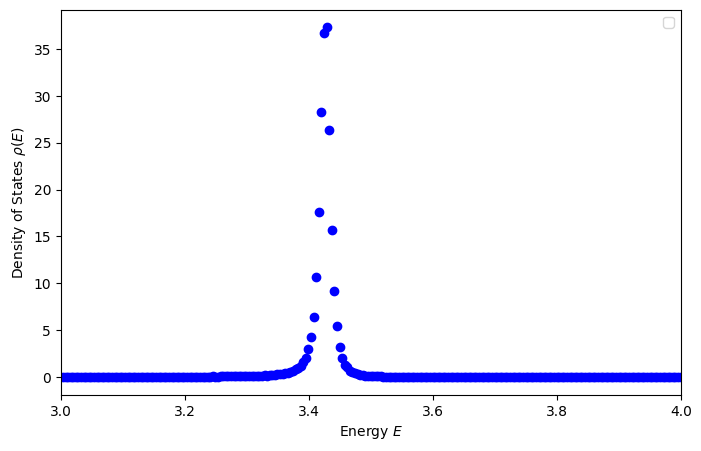

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(e_centers, rho, 'bo')
plt.xlabel("Energy $E$")
plt.ylabel("Density of States $\\rho(E)$")
#plt.ylim(0,1)
plt.xlim(3,4)
plt.legend()
plt.show()

In [ ]:
from scipy.optimize import curve_fit

def resonance_fit(E,a,b,Er,gamma):
    bg = a * E + b
    lorentz = ((1/np.pi) * (gamma/2) / ((E - Er)**2 + (gamma/2)**2))
    return bg + lorentz

# 1. Filter out the E=0 spike
mask = e_centers > 2
x_fit = e_centers[mask]
y_fit = rho_plain[mask]


initials = [0.001, 0.01, 3.45, 0.001] 

popt, pcov = curve_fit(resonance_fit, x_fit, y_fit, p0=initials)

Er_lit, Gamma_lit = 3.426, 0.0255

print(f"\n{'':20} {'Computed':>12} {'Literature':>12}")
print(f"{'Er (a.u.)':20} {popt[2]:>12.4f} {Er_lit:>12.4f}")
print(f"{'Γ (a.u.)':20} {popt[3]:>12.4f} {Gamma_lit:>12.4f}")
print(f"{'τ = ħ/Γ (a.u.)':20} {hbar/popt[3]:>12.4f} {hbar/Gamma_lit:>12.4f}")

Resonance Position (Er): 3.451292822007592
Resonance Width (Gamma): 9.650714698012127e-05
Lifetime (tau): 10361.92687579897


In [ ]:
def fano_fit(E,a,b,Er,q,gamma):
    bg = a*E+b
    epsilon = (E-Er)/(gamma/2)
    fano = (q+epsilon)**2/(1+epsilon**2)
    return bg+fano

mask = e_centers > 2
x_fit_fano = e_centers[mask]
y_fit_fano = rho_fano[mask]

initials_fano = [0.001, 0.01, 3.45,10, 0.001] 

popt_fano, pcov_fano = curve_fit(fano_fit, x_fit_fano, y_fit_fano, p0=initials_fano)

print(f"Resonance Position (Er): {popt_fano[2]}")
print(f"Fano asymmetry parameter (q): {popt_fano[3]}")
print(f"Resonance Width (Gamma): {popt_fano[4]}")
print(f"Lifetime (tau): {hbar / popt_fano[4]}")


Resonance Position (Er): 3.428847003503282
Resonance Width (Gamma): 6.335081398812292
Lifetime (tau): -0.016044123596472542
